In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("./data")
MAXWSPD_DIR = DATA_DIR / "maxwspd_interval1h"
BEST_TRACK_FILE = DATA_DIR / "best_track_Ragasa_JMA.xlsx"
OUTPUT_FILE = Path("intensity_error_barplot.tif")

FORECAST_INIT_TIMES = {
    "24h": pd.Timestamp("2025-09-22 22:00"),
    "48h": pd.Timestamp("2025-09-21 22:00"),
}
MODEL_STYLES = {
    "era5": {"label": "ERA5", "color": "#4c78a8"},
    "pangu": {"label": "Pangu", "color": "#f58518"},
    "graphcast": {"label": "GraphCast", "color": "#54a24b"},
    "fengwu": {"label": "FengWu", "color": "#e45756"},
    "fuxi": {"label": "FuXi", "color": "#72b7b2"},
    "aurora": {"label": "Aurora", "color": "#b279a2"},
}

PLOT_SETTINGS = {
    # Wide but short (reduce perceived bar height)
    "figure_size": (8, 4),
    "cycle_order": ["24h", "48h"],
    # Match Fig4/02_rmse_all_stations lead colors (same as 03_track_error.ipynb)
    "cycle_colors": {"24h": "#6E8BC3", "48h": "#C96A5A"},
    "bar_width": 0.36,
    "label_fontsize": 16,
    "text_fontsize": 14,
}
KT_TO_MS = 0.514444

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14


def load_maxwspd_forecast(model_name, cycle_name, init_time):
    file_path = MAXWSPD_DIR / f"maxwspd_d01_interval1h_{model_name}_{cycle_name}.txt"
    values = np.atleast_2d(np.loadtxt(file_path))
    lead_hours = np.arange(values.shape[0], dtype=int)

    return pd.DataFrame(
        {
            "model": model_name,
            "cycle": cycle_name,
            "lead_hour": lead_hours,
            "init_time": pd.Timestamp(init_time),
            "valid_time": pd.Timestamp(init_time) + pd.to_timedelta(lead_hours, unit="h"),
            "lon": values[:, 0],
            "lat": values[:, 1],
            "forecast_maxwind_ms": values[:, 2],
        }
    )


def load_best_track(file_path):
    return (
        pd.read_excel(file_path)
        .rename(columns={"Time": "time", "Wind": "wind_kt"})
        .assign(
            time=lambda frame: pd.to_datetime(frame["time"].astype(str), format="%y%m%d%H"),
            wind_kt=lambda frame: pd.to_numeric(frame["wind_kt"], errors="coerce"),
            wind_ms=lambda frame: pd.to_numeric(frame["wind_kt"], errors="coerce") * KT_TO_MS,
        )
        [["time", "wind_kt", "wind_ms"]]
        .dropna(subset=["time", "wind_ms"])
        .sort_values("time")
        .reset_index(drop=True)
    )


def load_all_maxwspd_forecasts():
    return {
        cycle_name: {
            model_name: load_maxwspd_forecast(model_name, cycle_name, init_time)
            for model_name in MODEL_STYLES
        }
        for cycle_name, init_time in FORECAST_INIT_TIMES.items()
    }


best_track = load_best_track(BEST_TRACK_FILE)
maxwspd_forecasts = load_all_maxwspd_forecasts()

In [2]:
def get_best_track_steps(best_track_frame, cycle_name, cycle_forecasts):
    forecast_start = FORECAST_INIT_TIMES[cycle_name]
    forecast_end = min(track["valid_time"].max() for track in cycle_forecasts.values())

    best_track_window = (
        best_track_frame.loc[best_track_frame["time"].between(forecast_start, forecast_end)]
        .copy()
        .sort_values("time")
    )

    return best_track_window.rename(
        columns={"time": "valid_time", "wind_ms": "best_wind_ms", "wind_kt": "best_wind_kt"}
    )[["valid_time", "best_wind_ms", "best_wind_kt"]]


def compute_intensity_error_table(best_track_frame, forecast_map):
    error_frames = []

    for cycle_name, cycle_forecasts in forecast_map.items():
        best_track_steps = get_best_track_steps(best_track_frame, cycle_name, cycle_forecasts)

        for model_name, forecast_track in cycle_forecasts.items():
            aligned_track = (
                forecast_track.merge(best_track_steps, on="valid_time", how="inner")
                .sort_values("valid_time")
                .reset_index(drop=True)
            )
            aligned_track["intensity_error_ms"] = (
                aligned_track["forecast_maxwind_ms"] - aligned_track["best_wind_ms"]
            ).abs()
            error_frames.append(
                aligned_track[
                    [
                        "cycle",
                        "model",
                        "lead_hour",
                        "valid_time",
                        "forecast_maxwind_ms",
                        "best_wind_ms",
                        "best_wind_kt",
                        "intensity_error_ms",
                    ]
                ]
            )

    return pd.concat(error_frames, ignore_index=True)


def summarize_intensity_error(intensity_error_frame):
    return (
        intensity_error_frame.groupby(["cycle", "model"], as_index=False)["intensity_error_ms"]
        .mean()
        .rename(columns={"intensity_error_ms": "mae_ms"})
    )


def format_intensity_error_summary(intensity_error_summary_frame):
    return (
        intensity_error_summary_frame.assign(
            model=lambda frame: frame["model"].map(lambda name: MODEL_STYLES[name]["label"])
        )
        .sort_values(["model", "cycle"])
        .reset_index(drop=True)
    )


intensity_error_table = compute_intensity_error_table(best_track, maxwspd_forecasts)
intensity_error_summary = summarize_intensity_error(intensity_error_table)

intensity_error_table.head(), format_intensity_error_summary(intensity_error_summary)

(  cycle model  lead_hour          valid_time  forecast_maxwind_ms  \
 0   24h  era5          2 2025-09-23 00:00:00              45.3236   
 1   24h  era5          8 2025-09-23 06:00:00              45.9336   
 2   24h  era5         14 2025-09-23 12:00:00              47.6714   
 3   24h  era5         20 2025-09-23 18:00:00              41.1298   
 4   24h  era5         26 2025-09-24 00:00:00              37.6300   
 
    best_wind_ms  best_wind_kt  intensity_error_ms  
 0      54.01662           105             8.69302  
 1      51.44440           100             5.51080  
 2      51.44440           100             3.77300  
 3      51.44440           100            10.31460  
 4      48.87218            95            11.24218  ,
    cycle      model    mae_ms
 0    24h     Aurora  6.365943
 1    48h     Aurora  5.045230
 2    24h       ERA5  8.820960
 3    48h       ERA5  5.512340
 4    24h     FengWu  7.316143
 5    48h     FengWu  6.024580
 6    24h       FuXi  5.563443
 7    48h  

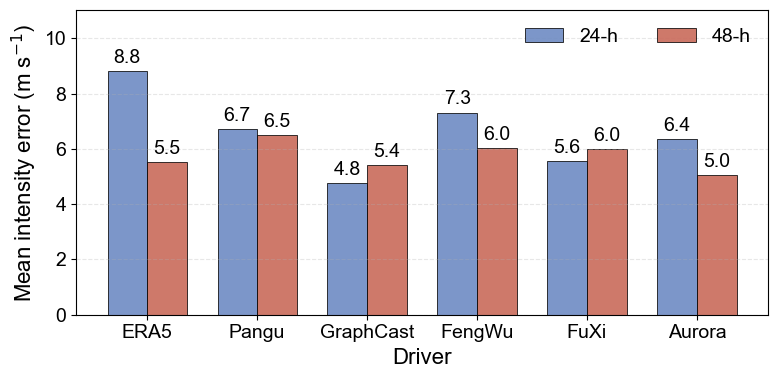

,cycle,model,mae_ms
0,24h,Aurora,6.365943
1,48h,Aurora,5.045230
2,24h,ERA5,8.820960
3,48h,ERA5,5.512340
4,24h,FengWu,7.316143
5,48h,FengWu,6.024580
6,24h,FuXi,5.563443
7,48h,FuXi,5.989760
8,24h,GraphCast,4.753543
9,48h,GraphCast,5.410960


In [3]:
def plot_intensity_error_summary(intensity_error_summary_frame):
    figure, axis = plt.subplots(figsize=PLOT_SETTINGS["figure_size"])
    model_order = list(MODEL_STYLES)
    x_positions = np.arange(len(model_order), dtype=float)

    for cycle_index, cycle_name in enumerate(PLOT_SETTINGS["cycle_order"]):
        cycle_summary = (
            intensity_error_summary_frame.loc[intensity_error_summary_frame["cycle"] == cycle_name]
            .set_index("model")
            .reindex(model_order)
            .reset_index()
        )
        x_offset = (cycle_index - 0.5) * PLOT_SETTINGS["bar_width"]
        legend_label = f"{cycle_name[:-1]}-h" if cycle_name.endswith("h") else cycle_name
        bars = axis.bar(
            x_positions + x_offset,
            cycle_summary["mae_ms"],
            width=PLOT_SETTINGS["bar_width"],
            label=legend_label,
            color=PLOT_SETTINGS["cycle_colors"][cycle_name],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9,
        )
        axis.bar_label(
            bars,
            fmt="%.1f",
            padding=3,
            fontsize=PLOT_SETTINGS["text_fontsize"],
        )

    axis.set_xticks(x_positions)
    axis.set_xticklabels(
        [MODEL_STYLES[model_name]["label"] for model_name in model_order],
        rotation=0,
        fontsize=PLOT_SETTINGS["text_fontsize"],
    )
    axis.tick_params(axis="y", labelsize=PLOT_SETTINGS["text_fontsize"])
    axis.set_ylabel(
        "Mean intensity error (m s$^{-1}$)", fontsize=PLOT_SETTINGS["label_fontsize"]
    )
    axis.set_xlabel("Driver", fontsize=PLOT_SETTINGS["label_fontsize"])

    y_max = float(intensity_error_summary_frame["mae_ms"].max()) if not intensity_error_summary_frame.empty else 0.0
    axis.set_ylim(0, max(1.0, y_max * 1.25))

    axis.grid(axis="y", linestyle="--", alpha=0.3)
    axis.legend(
        frameon=False,
        loc="upper right",
        ncol=2,
        fontsize=PLOT_SETTINGS["text_fontsize"],
        title_fontsize=PLOT_SETTINGS["text_fontsize"],
    )

    figure.tight_layout()
    figure.savefig(OUTPUT_FILE, dpi=600, format="tif", bbox_inches="tight")
    return figure, axis


fig, ax = plot_intensity_error_summary(intensity_error_summary)
plt.show()

format_intensity_error_summary(intensity_error_summary)

In [ ]:
# Self-contained Ragasa + Yagi mean intensity-error heatmap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HEATMAP_INPUT_DIR = Path("./input")
HEATMAP_OUTPUT_DIR = Path("./output")
HEATMAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HEATMAP_OUTPUT_FILE = HEATMAP_OUTPUT_DIR / "intensity_error_heatmap.tif"

HEATMAP_MODELS = {
    "era5": "ERA5",
    "pangu": "Pangu",
    "graphcast": "GraphCast",
    "fengwu": "FengWu",
    "fuxi": "FuXi",
    "aurora": "Aurora",
}
HEATMAP_CYCLES = ("24h", "48h")
HEATMAP_STORM_CONFIG = {
    "Ragasa": {
        "maxwspd_dir": HEATMAP_INPUT_DIR / "maxwspd_interval1h_ragasa",
        "file_template": "maxwspd_d01_interval1h_{model}_{cycle}.txt",
        "best_track_file": HEATMAP_INPUT_DIR / "best_track_Ragasa_JMA.xlsx",
        "time_step_hours": 1,
        "init_times": {
            "24h": pd.Timestamp("2025-09-22 22:00"),
            "48h": pd.Timestamp("2025-09-21 22:00"),
        },
        "end_time": pd.Timestamp("2025-09-24 10:00"),
        "skip_initial_points": 0,
        "expected_raw_points": {"24h": 37, "48h": 61},
        "expected_aligned_points": {"24h": 6, "48h": 10},
    },
    "Yagi": {
        "maxwspd_dir": HEATMAP_INPUT_DIR / "maxwspd_inteerval6h_yagi",
        "file_template": "maxwspd_yagi_{model}_{cycle}.txt",
        "best_track_file": HEATMAP_INPUT_DIR / "best_track_Yagi_JMA.xlsx",
        "time_step_hours": 6,
        "init_times": {
            "24h": pd.Timestamp("2024-09-04 12:00"),
            "48h": pd.Timestamp("2024-09-03 12:00"),
        },
        "end_time": pd.Timestamp("2024-09-06 00:00"),
        "skip_initial_points": 1,
        "expected_raw_points": {"24h": 9, "48h": 13},
        "expected_aligned_points": {"24h": 6, "48h": 10},
    },
}
HEATMAP_ROW_ORDER = [
    "Ragasa 24-h",
    "Ragasa 48-h",
    "Yagi 24-h",
    "Yagi 48-h",
]
HEATMAP_KT_TO_MS = 0.514444


def heatmap_load_best_track(file_path):
    best_track = (
        pd.read_excel(file_path)
        .rename(columns={"Time": "valid_time", "Wind": "wind_kt"})
        .assign(
            valid_time=lambda frame: pd.to_datetime(
                frame["valid_time"].astype(str), format="%y%m%d%H"
            ),
            best_wind_ms=lambda frame: pd.to_numeric(
                frame["wind_kt"], errors="coerce"
            )
            * HEATMAP_KT_TO_MS,
        )
        [["valid_time", "best_wind_ms"]]
        .dropna(subset=["valid_time", "best_wind_ms"])
        .sort_values("valid_time")
        .reset_index(drop=True)
    )
    assert np.isfinite(best_track["best_wind_ms"]).all(), file_path
    assert not best_track["valid_time"].duplicated().any(), file_path
    return best_track


def heatmap_load_forecast(storm_name, model_name, cycle_name):
    config = HEATMAP_STORM_CONFIG[storm_name]
    file_path = config["maxwspd_dir"] / config["file_template"].format(
        model=model_name, cycle=cycle_name
    )
    values = np.atleast_2d(np.loadtxt(file_path))
    assert values.shape[1] >= 3 and np.isfinite(values).all(), file_path
    assert len(values) == config["expected_raw_points"][cycle_name], (
        storm_name, cycle_name, model_name, len(values)
    )

    lead_hours = np.arange(values.shape[0], dtype=int) * config["time_step_hours"]
    init_time = config["init_times"][cycle_name]
    return pd.DataFrame(
        {
            "storm": storm_name,
            "cycle": cycle_name,
            "model": model_name,
            "valid_time": init_time + pd.to_timedelta(lead_hours, unit="h"),
            "forecast_maxwind_ms": values[:, -1],
        }
    )


def heatmap_build_intensity_errors():
    error_frames = []

    for storm_name, config in HEATMAP_STORM_CONFIG.items():
        best_track = heatmap_load_best_track(config["best_track_file"])
        for cycle_name in HEATMAP_CYCLES:
            for model_name in HEATMAP_MODELS:
                forecast = heatmap_load_forecast(storm_name, model_name, cycle_name)
                aligned = (
                    forecast.loc[forecast["valid_time"] <= config["end_time"]]
                    .merge(best_track, on="valid_time", how="inner", validate="one_to_one")
                    .sort_values("valid_time")
                    .reset_index(drop=True)
                )
                aligned = aligned.iloc[config["skip_initial_points"] :].reset_index(
                    drop=True
                )
                expected_points = config["expected_aligned_points"][cycle_name]
                assert len(aligned) == expected_points, (
                    storm_name, cycle_name, model_name, len(aligned)
                )

                aligned["intensity_error_ms"] = (
                    aligned["forecast_maxwind_ms"] - aligned["best_wind_ms"]
                ).abs()
                assert np.isfinite(aligned["intensity_error_ms"]).all()
                error_frames.append(aligned)

    return pd.concat(error_frames, ignore_index=True)


heatmap_intensity_errors = heatmap_build_intensity_errors()
heatmap_intensity_error_summary = (
    heatmap_intensity_errors.groupby(
        ["storm", "cycle", "model"], as_index=False, sort=False
    )
    .agg(
        count=("intensity_error_ms", "count"),
        mean_intensity_error_ms=("intensity_error_ms", "mean"),
    )
)
heatmap_intensity_error_summary["row_label"] = (
    heatmap_intensity_error_summary["storm"]
    + " "
    + heatmap_intensity_error_summary["cycle"].map(
        {"24h": "24-h", "48h": "48-h"}
    )
)

heatmap_data = (
    heatmap_intensity_error_summary.pivot(
        index="row_label", columns="model", values="mean_intensity_error_ms"
    )
    .reindex(index=HEATMAP_ROW_ORDER, columns=list(HEATMAP_MODELS))
    .rename(columns=HEATMAP_MODELS)
)
assert heatmap_data.shape == (4, 6)
assert np.isfinite(heatmap_data.to_numpy()).all()
assert heatmap_data.to_numpy().min() >= 0
heatmap_data.index = ["Ragasa 24h", "Ragasa 48h", "Yagi 24h", "Yagi 48h"]

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 18
figure, axis = plt.subplots(figsize=(10, 4.8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Mean intensity error (m s$^{-1}$)", "pad": 0.02},
    annot_kws={"fontsize": 18},
    ax=axis,
)
axis.axhline(2, color="black", linewidth=1.5)
axis.set_xlabel("Driver", fontsize=20)
axis.set_ylabel("")
axis.set_xticklabels(axis.get_xticklabels(), rotation=0, fontsize=16)
axis.set_yticklabels(axis.get_yticklabels(), rotation=0, fontsize=18)
colorbar = axis.collections[0].colorbar
colorbar.ax.tick_params(labelsize=18)
colorbar.set_label("Mean intensity error (m s$^{-1}$)", fontsize=20)
figure.tight_layout()
figure.savefig(HEATMAP_OUTPUT_FILE, dpi=600, format="tif", bbox_inches="tight")
plt.show()

heatmap_data
